<font size="5"> <a href="https://uspdigital.usp.br/jupiterweb/obterDisciplina?sgldis=MAC0209"> Exercício de MAC0209 - Modelagem e Simulação</a> </font>

Guilherme França Carvalho - 15554267  

Ismália Alves Santos Ziemer - 16873442  

João Victor Bispo do Nascimento - 16907592  

Leonardo Heidi Almeida Murakami - 11260186  

Luis Renato Ferraz Natil Martins - 13726021  

Murilo Freitas Yonashiro Coelho - 8587476  

Vítor Gonçalves Serra - 11265282  

Vitor Wallace de Moraes Alves - 8610353  


***
<font size="5">EP03 - Voo de drones</font>
***

# Modelagem

### Fase 1

Durante a primeira fase, o drone parte do repouso e acelera com aceleração $a_0$ até atingir velocidade $v_0$.
A partir da seguinte equações, obtemos as expressões das funções necessárias.

$$\frac{dv}{dt} = a_0 \\
\frac{dx}{dt} = v(t) = a_0t\\
x(t) = \frac12 a_0 t^2.$$

Como o drone parte do repouso, temos $v(0) = 0$ e assumiremos $x(0) = 0$. Como o drone para quando a velocidade $v(t)$ atinge $v_0$, queremos achar $t_1$ tal que $v(t_1) = v_0$. Então

$$v(t_1) = v_0\\
a_0t_1 = v_0\\
t_1 = \frac{v_0}{a_0}, \text{ para }a_0 \neq 0.$$

### Fase 2

A partir da segunda fase, o drone se movimenta com velocidade constante $v_0$, até atingir o tempo $t_2$. Usando os valores expressados anteriormente, temos as seguintes equações:

$$\frac{dv}{dt} = 0 \\ \frac{dx}{dt} = v(t) = v_0$$
$$ x(t) = v_0(t-t_1) + x(t_1) $$

Usando a expressão da primeira fase para $x(t)$, achamos $x(t_1)$.

$$x(t_1) = \frac12 a_0 t_1^2 = \frac12 a_0 \left(\frac{v_0}{a_0}\right)^2 = \frac{v_0^2}{2a_0}$$

Usando isso, simplificamos a expressão de $x(t)$.

$$x(t) = v_0\left(t-\frac{v_0}{a_0}\right) + \frac{v_0^2}{2a_0} = v_0\left(t-\frac{v_0}{2a_0}\right) = v_0\left(t-\frac{t_1}{2}\right).$$

### Fase 3

Na última fase, o drone desacelera com aceleração $-a_0$ até parar $v(t_3) = 0$.

$$ \frac{dv}{dt} = -a_0 \\
\frac{dx}{dt} = v(t) = -a_0(t-t_2) + v_0 \\
x(t) = -\frac{a_0}2 (t-t_2)^2 + v_0(t-t_2) + x(t_2) $$

Onde

$$x(t_2) = v_0\left(t_2 - \frac{t_1}2\right).$$

Simplificando:

$$x(t) = -\frac{a_0}2 (t-t_2)^2 + v_0(t-t_2) + v_0\left(t_2 - \frac{t_1}2\right) =-\frac{a_0}2 (t-t_2)^2 + v_0\left(t - \frac{t_1}2\right).$$

Para obter $t_3$, fazemos $v(t_3) = 0$.

$$v(t_3) = 0\\
-a_0(t_3 - t_2) + v_0 = 0\\
t_3 - t_2 = \frac{v_0}{a_0}\\
t_3 = \frac{v_0}{a_0} + t_2 = t_1 + t_2.$$

Assim, podemos obter a posição final, $x(t_3)$.

$$x(t_3) = -\frac{a_0}2 (t_3-t_2)^2 + v_0\left(t_3 - \frac{t_1}2\right)\\
= -\frac{a_0}2 (t_2+t_1-t_2)^2 + v_0\left(t_2+t_1 - \frac{t_1}2\right)\\
= -\frac{a_0}2 t_1^2 + v_0\left(t_2 + \frac{t_1}2\right)\\
= -\frac{a_0}2 \frac{v_0}{a_0} t_1 + v_0\left(t_2 + \frac{t_1}2\right)\\
= v_0\left( -\frac{t_1}2\right) + v_0 \left(t_2 + \frac{t_1}2\right)\\
= v_0\left( -\frac{t_1}2 + t_2 + \frac{t_1}2\right)
= v_0t_2.$$

# Setup

In [7]:
# Bibliotecas
import math
import matplotlib.pyplot as plt
import numpy as np

# Parâmetros
a0 = 2.0
v0 = 10.0
t2 = 10.0

## Método Analítica

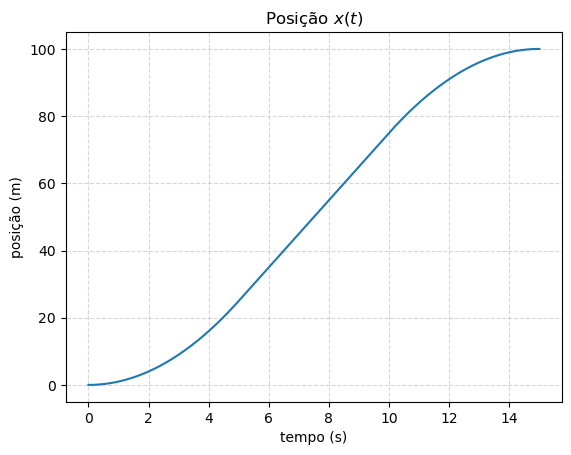

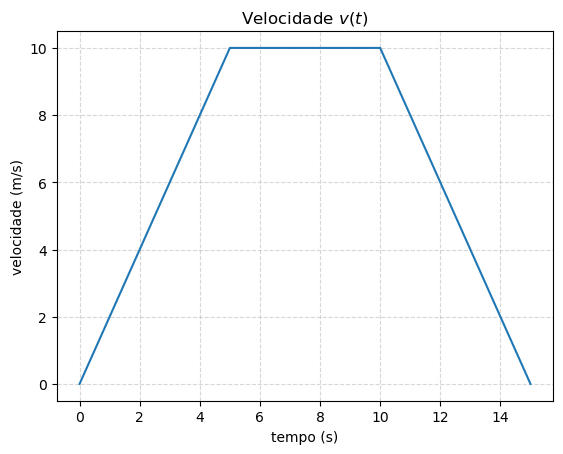

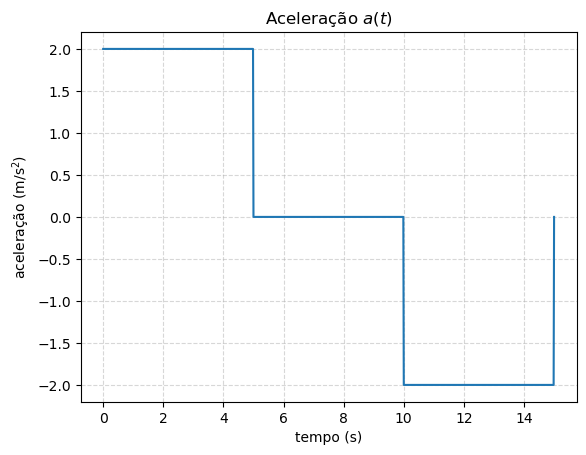

In [27]:
# Implementação

t1 = v0/a0
t3 = t1 + t2
assert(t1<t2)

def x_t(t):
    if t<t1:
        return 0.5*a0 * t*t
    elif t<t2:
        return v0 * (t - 0.5*t1)
    elif t<t3:
        return -0.5*a0 * (t-t2)**2 + v0 * (t - 0.5*t1)
    else:
        return v0 * t2
    
def v_t(t):
    if t<t1:
        return a0*t
    elif t<t2:
        return v0
    elif t<t3:
        return v0 - a0*(t-t2)
    else:
        return 0
    
def a_t(t):
    if t<t1:
        return a0
    elif t<t2:
        return 0
    elif t<t3:
        return -a0
    else:
        return 0

### Amostragem do tempo
t = np.linspace(0, t3, 1000)

### Calculo das funções
x = np.array([x_t(ti) for ti in t])
v = np.array([v_t(ti) for ti in t])
a = np.array([a_t(ti) for ti in t])

plt.plot(t,x)
plt.xlabel(r'tempo (s)')
plt.ylabel(r'posição (m)')
plt.title("Posição $x(t)$")
plt.grid(linestyle='--', alpha=0.5)
plt.show()

plt.plot(t,v)
plt.xlabel(r'tempo (s)')
plt.ylabel(r'velocidade (m/s)')
plt.title("Velocidade $v(t)$")
plt.grid(linestyle='--', alpha=0.5)
plt.show()

plt.plot(t,a)
plt.xlabel(r'tempo (s)')
plt.ylabel(r'aceleração (m/s$^2$)')
plt.title("Aceleração $a(t)$")
plt.grid(linestyle='--', alpha=0.5)
plt.show()